<a href="https://colab.research.google.com/github/Juana-Zhang/Casual-Inference/blob/main/Project_Incremental_Conversion_Modeling_(Uplift_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Incremental Conversion Modeling (Uplift Analysis) -Fetch_Criteo

- Nuonan Zhang



### **Business Context**
Traditional A/B testing tells us if a campaign works on average, but it doesn't tell us **who** to target. To optimize marketing efficiency, we categorize users into four segments:
* **Sure Things**: Users who will convert whether they see an ad or not. Targeting them is a waste of budget.
* **Persuadables**: Users who only convert *if* they see an ad. This is the **primary target** for maximizing ROI.
* **Lost Causes**: Users who will not convert even if they see an ad.
* **Sleeping Dogs**: Users who might be discouraged by ads (e.g., unsubscribing). Targeting them is counterproductive.

### **Business Goal (BG)**
The objective is to **maximize Marketing ROI** by identifying the **"Persuadable"** user segment.

**Core Strategy:**
By predicting the **Incremental Lift (Uplift)** for each individual, we can:
1.  **Optimize Budget Allocation**: Focus spending exclusively on users where the ad causes a genuine change in behavior.
2.  **Reduce Waste**: Eliminate spend on "Sure Things" and "Lost Causes."
3.  **Prevent Churn**: Avoid negative impact on "Sleeping Dogs."

### Step 1: Environment Setup & Data Ingestion

**Logic:**
* **Installation**: Install `scikit-uplift` for specialized causal data handling and `catboost` for high-performance gradient boosting.
* **Data Fetching**: Fetch the **Criteo Uplift Dataset** (10% sample), which contains over 1.3 million anonymized records of user features, treatment indicators, and conversion labels.
* **Data Splitting**: Split the data into **Training (70%)** and **Testing (30%)** sets to ensure unbiased model evaluation.

In [2]:
# 1. Install necessary libraries
!pip install -q scikit-uplift catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklift.datasets import fetch_criteo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [3]:
from sklift.datasets import fetch_criteo

# 2. Fetch the Criteo dataset
print("Downloading Criteo dataset...")
dataset = fetch_criteo(target_col='conversion', treatment_col='treatment', percent10=True)
X, y, tr = dataset.data, dataset.target, dataset.treatment

# 3. Split into Train/Test sets
X_train, X_test, y_train, y_test, tr_train, tr_test = train_test_split(
    X, y, tr, test_size=0.3, random_state=42
)
print("Data ingestion complete.")

# 4. Data Preview
df_view = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])]).head(10)
df_view['treatment'] = tr[:10]
df_view['conversion'] = y[:10]
display(df_view)

Criteo dataset (10 percent):   0%|          | 0.00/32.0M [00:00<?, ?iB/s]

Data ingestion complete.


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion
0,26.290533,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0
1,12.616365,10.059654,8.339021,4.679882,10.280525,4.115453,0.294443,4.833815,3.869313,32.101873,5.300375,-0.168679,0,0
2,17.293231,10.059654,8.214383,2.293959,10.280525,4.115453,-4.595460,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0
3,12.616365,10.059654,8.788121,4.679882,10.280525,4.115453,0.294443,4.833815,3.943716,13.190056,5.300375,-0.168679,0,0
4,20.363292,10.059654,8.563419,2.934780,10.280525,4.115453,-12.570178,4.833815,3.863287,18.380112,5.300375,-0.168679,1,0
5,12.616365,10.059654,8.966896,4.679882,10.280525,4.115453,0.294443,4.833815,3.943716,13.190056,5.300375,-0.168679,1,0
6,12.616365,10.059654,8.909030,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,-0.168679,0,0
7,12.616365,10.059654,8.240491,4.679882,11.029584,4.115453,0.294443,4.833815,3.737472,45.811645,6.453283,-0.168679,1,0
8,26.494123,10.059654,8.214383,4.679882,10.280525,4.115453,-3.282109,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0
9,12.616365,10.059654,8.630242,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,20.050937,5.300375,-0.168679,1,0


### Step 2: A/B Test Audit & Balance Check


### **Logic**:

* **ATE Calculation**: Calculate the **Average Treatment Effect (ATE)**, which is the raw difference in conversion rates between the Treatment and Control groups.

* **Balance Check**: Use a Kernel Density Estimate (KDE) plot to verify that user features (like f0) are distributed
identically across both groups to confirm successful randomization.

## Cell 2: A/B Test


--- Standard A/B Test Results ---
Control Group CVR: 0.2101%
Treatment Group CVR: 0.3284%
Overall Incremental Lift (ATE): 0.1184%


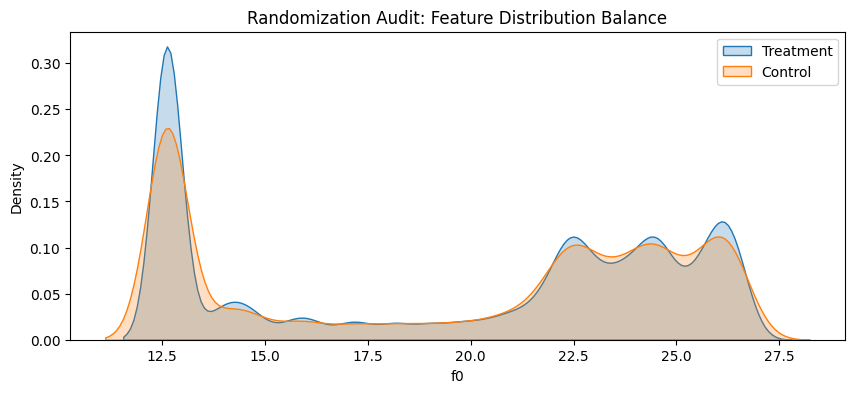

In [6]:
# Calculate ATE
cvr_t = y_test[tr_test == 1].mean()
cvr_c = y_test[tr_test == 0].mean()
ate = cvr_t - cvr_c

print(f"--- Standard A/B Test Results ---")
print(f"Control Group CVR: {cvr_c:.4%}")
print(f"Treatment Group CVR: {cvr_t:.4%}")
print(f"Overall Incremental Lift (ATE): {ate:.4%}")

# Covariate Balance Check
plt.figure(figsize=(10, 4))
sns.kdeplot(X_train[tr_train == 1]['f0'], label='Treatment', fill=True)
sns.kdeplot(X_train[tr_train == 0]['f0'], label='Control', fill=True)
plt.title("Randomization Audit: Feature Distribution Balance")
plt.legend()
plt.show()

### Step 3: Causal Inference Modeling (S-Learner)

**Logic:**
* **Approach**: Implement an **S-Learner** (Single Learner) framework where the `treatment` indicator is treated as a standard feature during training.
* **Counterfactual Prediction**: For each test user, simulate two "parallel worlds" (Counterfactuals) to predict conversion probabilities if they saw the ad vs. if they did not.
* **Uplift Score**: The difference ($prob\_1 - prob\_0$) represents the **Conditional Average Treatment Effect (CATE)** for that individual.

In [7]:
from catboost import CatBoostClassifier

# 1. Train model with treatment as a feature
X_train_s = X_train.copy()
X_train_s['treatment'] = tr_train

model = CatBoostClassifier(iterations=100, silent=True, random_state=42)
model.fit(X_train_s, y_train)

# 2. Counterfactual Predictions for Test Set
X_test_1 = X_test.copy()
X_test_1['treatment'] = 1
prob_1 = model.predict_proba(X_test_1)[:, 1]

X_test_0 = X_test.copy()
X_test_0['treatment'] = 0
prob_0 = model.predict_proba(X_test_0)[:, 1]

# 3. Calculate predicted Uplift Scores
uplift_scores = prob_1 - prob_0
print("Individual Uplift Scores calculated.")

Individual Uplift Scores calculated.


### Step 4: Model Validation & Business Impact

**Logic:**
* **Decile Analysis**: Partition the test population into 10 equal groups (deciles) based on predicted Uplift Scores.
* **Observed Lift Validation**: Measure the actual conversion rate difference in each decile to validate the model's ranking ability.
* **Business Strategy**: Focus marketing budget on the most responsive deciles (Persuadables) to maximize ROI.

/tmp/ipython-input-1018/315570690.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = results.groupby('decile').apply(


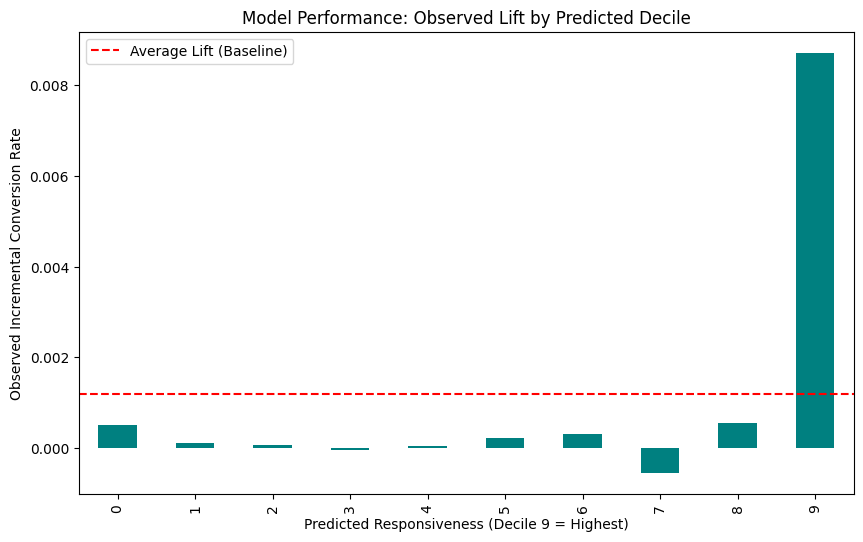

Key Insight: The top 10% most responsive segment shows a lift 7.4x higher than the average.


In [8]:
## 1. Rank users into Deciles
results = pd.DataFrame({'uplift': uplift_scores, 'tr': tr_test, 'y': y_test})
results['decile'] = pd.qcut(results['uplift'], 10, labels=False)

# 2. Calculate actual observed lift per decile
summary = results.groupby('decile').apply(
    lambda x: x[x['tr'] == 1]['y'].mean() - x[x['tr'] == 0]['y'].mean()
)

# 3. Visualize Impact
plt.figure(figsize=(10, 6))
summary.plot(kind='bar', color='teal')
plt.axhline(ate, color='red', linestyle='--', label='Average Lift (Baseline)')
plt.title("Model Performance: Observed Lift by Predicted Decile")
plt.xlabel("Predicted Responsiveness (Decile 9 = Highest)")
plt.ylabel("Observed Incremental Conversion Rate")
plt.legend()
plt.show()

# 4. Strategic Conclusion
top_group_lift = summary.iloc[-1]
print(f"Key Insight: The top 10% most responsive segment shows a lift {top_group_lift/ate:.1f}x higher than the average.")


### **Project Impact & Executive Summary**
* **Precision Targeting**: Successfully identified a high-responsiveness segment (Top Decile) exhibiting an incremental lift **7.4 times higher** than the random-targeting baseline.
* **ROI Maximization**: Focusing spend on "Persuadables" captures the majority of incremental conversions while reducing waste on "Sure Things" or "Lost Causes".
* **Risk Mitigation**: The analysis identified segments (e.g., Decile 7) where advertising had a **negative effect**, allowing the business to prevent potential churn among "Sleeping Dogs".
* **Causal Insight**: This framework transforms marketing into a precision revenue-driver by quantifying the true **causal impact** of ads.